# **Spring 2026 Deep Learning (CSCI-4701 - 20295)**
**Team Project** - **FocusGame**

*Laman Panakhova BSCS 2026*

# Project Goal

The goal of this project is to build a deep learning model that can automatically detect **cardiomegaly (an enlarged heart)** from chest X-ray images. Cardiomegaly is an important sign that may indicate several heart conditions, so detecting it early can help doctors with diagnosis and treatment.

In this project, we use the CheXpert-v1.0-small dataset (kaggle), which is a subset of the Stanford Large Chest X-Ray Dataset compiled by the Stanford ML Group. The dataset contains numerous chest X-ray images annotated with various medical findings, including cardiomegaly, atelectasis, consolidation, and pleural effusion.

To solve this problem, we train a **convolutional neural network (CNN)** using **PyTorch**. The model takes an X-ray image as input and predicts whether cardiomegaly is present. The system includes a full machine learning pipeline that loads the dataset, preprocesses the images, trains the model, and evaluates its performance.

Besides measuring overall model accuracy, we also check whether the model performs differently for **male and female patients**. Since medical datasets can sometimes contain biases or imbalances, it is important to see if predictions vary across different groups.

The goal of **Milestone 1** is to build this complete training and evaluation pipeline and run an initial experiment to measure model performance and analyze any differences between demographic groups.


In [ ]:
# WHAT:
# Import all required libraries for the deep learning pipeline.

# HOW:
# - General libraries (os, numpy, pandas) handle file paths, numerical operations, and dataset manipulation.
# - PIL loads and processes chest X-ray images.
# - tqdm provides progress bars during training loops.
# - PyTorch modules (torch, nn, optim, DataLoader) are used to build and train the neural network.
# - torchvision provides pretrained CNN architectures and image transformations.
# - sklearn metrics are used to evaluate model performance (accuracy, ROC-AUC, F1-score, confusion matrix).
# - kagglehub is used to download the CheXpert dataset. - https://www.kaggle.com/datasets/ashery/chexpert

# WHY:
# These libraries provide the tools needed to implement the full machine learning pipeline,
# including dataset loading, preprocessing, model training, and performance evaluation.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, f1_score

import kagglehub

In [ ]:
# WHAT:
# Set reproducibility and select the computation device.

# HOW:
# A fixed random seed (42) is applied to Python, NumPy, and PyTorch
# so that random operations produce consistent results across runs.
# The device is set to GPU (CUDA) if available, otherwise CPU.

# WHY:
# This ensures that experiments are reproducible and allows the model
# to use GPU acceleration when available for faster training.

In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# WHAT:
# Download the dataset and define paths to the training and validation files.

# HOW:
# The dataset is downloaded using kagglehub. After downloading,
# file paths for train.csv and valid.csv are created using os.path.

# WHY:
# These CSV files contain the image paths and labels needed to load
# the data and train the model for cardiomegaly detection.

# Dataset

This project uses the CheXpert-v1.0-small, which is a smaller version of the original CheXpert dataset developed for automated chest X-ray interpretation. The dataset contains 224,316 chest radiographs from 65,240 patients.

Each record in the dataset contains both an image and associated metadata. The metadata includes information such as the patient’s age, sex, image view type (frontal or lateral), and several diagnostic labels that indicate the presence of different thoracic conditions.

For this project, we focus specifically on the Cardiomegaly label, which indicates whether the X-ray image shows signs of an enlarged heart.

The dataset contains both frontal and lateral views, although frontal images represent the majority of the dataset and are generally more informative for cardiomegaly detection. The labels in the dataset were automatically extracted from radiology reports using natural language processing methods.

Some labels in the dataset are marked as uncertain (-1). In this project, uncertain values are treated as negative cases in order to simplify the classification task. Missing values are handled during preprocessing to ensure the dataset can be used for training without errors.

Before training the model, the images are resized and normalized so that they can be processed consistently by the neural network.

In [ ]:
dataset_path = kagglehub.dataset_download("ashery/chexpert")

train_csv = os.path.join(dataset_path,"train.csv")
valid_csv = os.path.join(dataset_path,"valid.csv")

Using Colab cache for faster access to the 'chexpert' dataset.


In [ ]:
# WHAT:
# Define a custom dataset class for loading CheXpert X-ray images.

# HOW:
# The class reads the dataset CSV file using pandas, optionally samples
# a subset of the data, and cleans the Cardiomegaly label by replacing
# missing and uncertain values. Each image is loaded from its path,
# transformed if needed, and returned together with its label and sex.

# WHY:
# A custom Dataset class allows PyTorch DataLoader to efficiently load
# images and labels during training and also provides patient sex
# information for the fairness experiment.

In [ ]:
class CheXpertDataset(Dataset):

    def __init__(self,csv_file,root_dir,transform=None,sample_size=None):

        self.df = pd.read_csv(csv_file)

        if sample_size:
            self.df = self.df.sample(sample_size,random_state=42)

        self.df["Cardiomegaly"] = self.df["Cardiomegaly"].fillna(0)
        self.df["Cardiomegaly"] = self.df["Cardiomegaly"].replace(-1,0)

        self.root=root_dir
        self.transform=transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):

        row=self.df.iloc[idx]

        rel=row["Path"].replace("CheXpert-v1.0-small/","")
        path=os.path.join(self.root,rel)

        image=Image.open(path).convert("RGB")

        if self.transform:
            image=self.transform(image)

        label=torch.tensor(row["Cardiomegaly"],dtype=torch.float32)

        return image,label,row["Sex"]

In [ ]:
# WHAT:
# Load the dataset and create basic visualizations to explore its structure.

# HOW:
# The training CSV file is loaded with pandas and the Cardiomegaly label
# is cleaned by replacing missing and uncertain values. Then three plots
# are created: sex distribution, cardiomegaly class distribution, and
# patient age distribution.

# WHY:
# These visualizations help understand the dataset before training,
# revealing demographic composition and potential class imbalance,
# which are important for interpreting model performance and fairness.

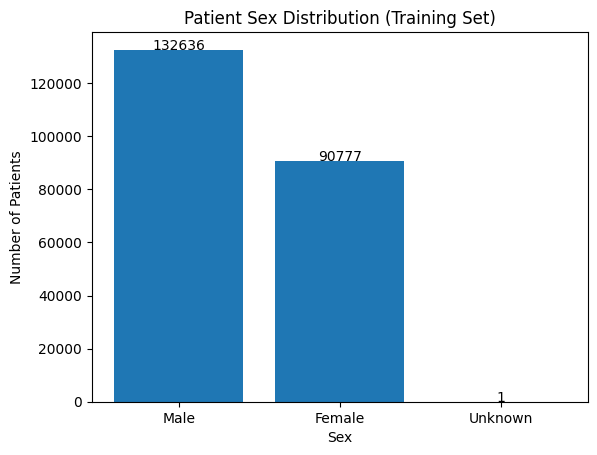

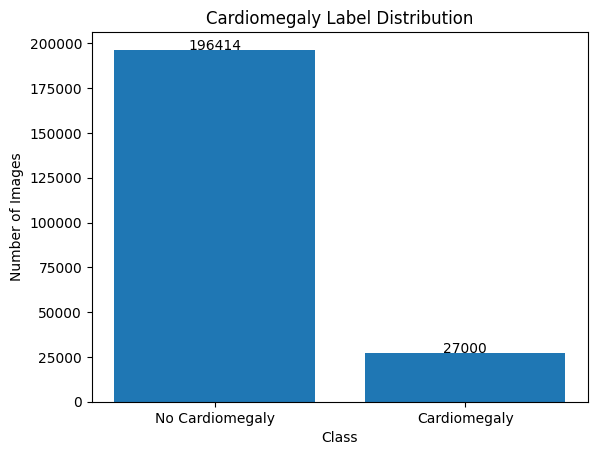

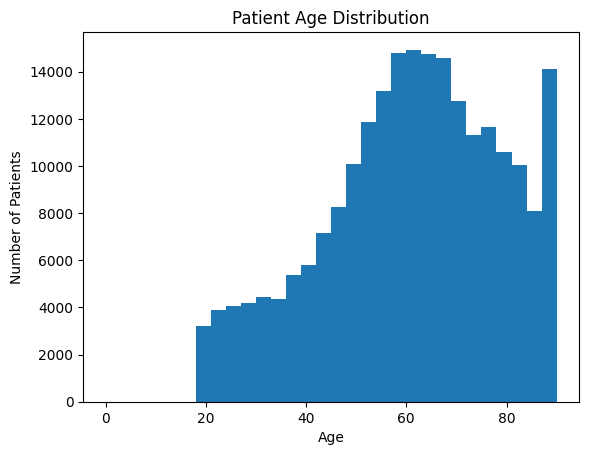

In [ ]:
df = pd.read_csv(train_csv)

# apply same cleaning used in training
df["Cardiomegaly"] = df["Cardiomegaly"].fillna(0)
df["Cardiomegaly"] = df["Cardiomegaly"].replace(-1,0)

# Visualization 1: Sex Distribution
sex_counts = df["Sex"].value_counts()

plt.figure()
plt.bar(sex_counts.index, sex_counts.values)
plt.title("Patient Sex Distribution (Training Set)")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")

for i,v in enumerate(sex_counts.values):
    plt.text(i, v+50, str(v), ha='center')

plt.show()


# Visualization 2: Cardiomegaly Label Distribution
label_counts = df["Cardiomegaly"].value_counts()

plt.figure()
plt.bar(["No Cardiomegaly","Cardiomegaly"], label_counts.values)

plt.title("Cardiomegaly Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

for i,v in enumerate(label_counts.values):
    plt.text(i, v+50, str(v), ha='center')

plt.show()


# Visualization 3: Age Distribution
ages = df["Age"].dropna()

plt.figure()
plt.hist(ages, bins=30)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

In [ ]:
# WHAT:
# Define image preprocessing and augmentation transformations.

# HOW:
# Training images use data augmentation such as random cropping,
# flipping, rotation, and color jitter to increase variability.
# Both training and validation images are converted to tensors
# and normalized using standard ImageNet statistics.

# WHY:
# Data augmentation helps the model generalize better by exposing
# it to slightly different versions of the same images, while
# normalization stabilizes training and ensures consistent input
# for the neural network.

In [ ]:
train_transform = transforms.Compose([

    transforms.RandomResizedCrop(380,scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

valid_transform = transforms.Compose([

    transforms.Resize((380,380)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
# WHAT:
# Create dataset objects and data loaders for training and validation.

# HOW:
# The custom CheXpertDataset class is used to load the training and
# validation data. A subset of 50,000 training samples is used for
# faster experimentation. PyTorch DataLoader then organizes the data
# into batches and enables efficient loading during training.

# WHY:
# DataLoaders improve training efficiency by batching images and
# shuffling the training data, which helps the model learn better
# and generalize more effectively.

In [ ]:
train_dataset = CheXpertDataset(train_csv,dataset_path,train_transform,50000)
valid_dataset = CheXpertDataset(valid_csv,dataset_path,valid_transform)

train_loader = DataLoader(train_dataset,batch_size=12,shuffle=True,num_workers=2)
valid_loader = DataLoader(valid_dataset,batch_size=12,shuffle=False,num_workers=2)

print("Train size:",len(train_dataset))
print("Valid size:",len(valid_dataset))

Train size: 50000
Valid size: 234


In [ ]:
# WHAT:
# Calculate class imbalance weight for the Cardiomegaly label.

# HOW:
# The labels for the "Cardiomegaly" condition are extracted from
# the training dataset dataframe. The positive class weight is
# computed using the ratio of negative samples to positive samples.
# This value is converted into a PyTorch tensor and moved to the
# training device (CPU/GPU).

# WHY:
# Medical datasets like CheXpert often have class imbalance,
# where negative cases greatly outnumber positive ones.
# Using a positive class weight helps the loss function give
# more importance to the minority (positive) class, improving
# the model's ability to detect Cardiomegaly.

In [ ]:
labels = train_dataset.df["Cardiomegaly"].values

pos_weight = torch.tensor((len(labels)-labels.sum())/labels.sum()).to(device)

In [ ]:
# WHAT:
# Load and configure the deep learning model for Cardiomegaly
# classification.

# HOW:
# A pretrained EfficientNet-B4 model is loaded from torchvision
# using default ImageNet weights. The final classifier layer is
# replaced with a new fully connected layer that outputs a single
# value, since this is a binary classification task (Cardiomegaly
# present or absent). The model is then moved to the selected
# device (CPU or GPU).

# WHY:
# Using a pretrained model (transfer learning) allows the network
# to start with strong visual feature representations learned from
# large datasets. Replacing the final layer adapts the model to the
# specific medical task of predicting Cardiomegaly.

# Model Architecture

To detect cardiomegaly from chest X-ray images, we use a pretrained convolutional neural network available in the PyTorch torchvision library. The model is based on EfficientNet-B4, which have been widely used for image classification tasks.

Instead of training the network entirely from scratch, we use transfer learning, which allows us to start from a model that has already learned general visual features from large image datasets such as ImageNet. This approach often improves training efficiency and performance, especially when working with medical datasets.

The final classification layer of the pretrained network is replaced with a single output neuron, since the task in this project is a binary classification problem (cardiomegaly vs. no cardiomegaly). The model outputs a probability that represents the likelihood that cardiomegaly is present in the image.

During training, a sigmoid activation function is applied to the output, and the model is optimized using binary cross-entropy loss, which measures the difference between the predicted probabilities and the true labels.

In [ ]:
model = models.efficientnet_b4(weights="DEFAULT")

model.classifier[1] = nn.Linear(model.classifier[1].in_features,1)

model = model.to(device)

In [ ]:
# WHAT:
# Define the training configuration including the loss function,
# optimizer, learning rate scheduler, mixed precision scaler,
# and number of training epochs.

# HOW:
# BCEWithLogitsLoss is used as the loss function for binary
# classification, with a positive class weight to handle class
# imbalance. AdamW is selected as the optimizer to update the
# model parameters efficiently while applying weight decay.
# CosineAnnealingLR gradually adjusts the learning rate following
# a cosine decay schedule across training epochs. GradScaler is
# used for mixed precision training on CUDA devices to improve
# performance and reduce memory usage. The total number of epochs
# is set to 12.

# WHY:
# This setup stabilizes and improves the training process.
# Weighted loss addresses class imbalance, AdamW provides
# effective optimization, cosine scheduling helps the model
# converge smoothly, and mixed precision speeds up training
# while using GPU memory more efficiently.

# Training Procedure

The model is trained using the training portion of the CheXpert dataset. During training, each image is passed through the neural network, and the predicted probability of cardiomegaly is compared with the ground truth label.

The difference between the predicted values and the true labels is calculated using the binary cross-entropy loss function. The model parameters are then updated using the Adam optimizer, which performs gradient-based optimization.

Training is performed over several epochs, where each epoch represents one complete pass through the training dataset. After each epoch, the model is evaluated on the validation dataset to monitor how well it generalizes to new, unseen images.

Before images are passed to the model, standard preprocessing steps are applied. These include resizing the images to a consistent input size and normalizing pixel values. These steps help stabilize the training process and improve the model’s ability to learn useful patterns.

In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(),lr=2e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=12)

scaler = torch.amp.GradScaler("cuda")

EPOCHS = 12

In [ ]:
# WHAT:
# Train the model over multiple epochs using the training dataset.

# HOW:
# For each epoch, the model is set to training mode and batches
# of images and labels are loaded from the DataLoader. Images and
# labels are moved to the training device. Mixed precision
# (autocast) is used to speed up computation. The model predicts
# outputs, the loss is calculated, and gradients are computed
# using backpropagation. GradScaler safely updates the model
# parameters. The learning rate scheduler is stepped after each
# epoch.

# WHY:
# This loop allows the model to learn patterns from the training
# data by continuously updating its weights. Mixed precision
# improves performance on GPUs, and batching through DataLoader
# ensures efficient training.

In [ ]:
for epoch in range(EPOCHS):

    model.train()
    total_loss=0

    for images,labels,_ in tqdm(train_loader):

        images=images.to(device)
        labels=labels.unsqueeze(1).to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):

            outputs=model(images)
            loss=criterion(outputs,labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss+=loss.item()

    scheduler.step()

    print("Epoch",epoch+1,"Loss:",total_loss/len(train_loader))

100%|██████████| 4167/4167 [19:51<00:00,  3.50it/s]


Epoch 1 Loss: 1.0081506947554757


100%|██████████| 4167/4167 [19:17<00:00,  3.60it/s]


Epoch 2 Loss: 0.891005984328478


100%|██████████| 4167/4167 [19:15<00:00,  3.61it/s]


...

Epoch 10 Loss: 0.43164021643211664


100%|██████████| 4167/4167 [18:54<00:00,  3.67it/s]


Epoch 11 Loss: 0.39568429013599316


100%|██████████| 4167/4167 [18:54<00:00,  3.67it/s]

Epoch 12 Loss: 0.3738969015540881


In [ ]:
# WHAT:
# Evaluate the trained model on the validation dataset using
# Test-Time Augmentation (TTA).

# HOW:
# The model is switched to evaluation mode and gradients are
# disabled to speed up inference. For each validation batch,
# predictions are generated multiple times (3 passes) using
# augmented inputs. The predicted probabilities are averaged
# to produce a more stable final prediction. Predictions,
# true labels, and patient sex information are stored for
# later analysis.

# WHY:
# Test-Time Augmentation improves prediction robustness by
# averaging outputs from multiple augmented versions of the
# same image. This reduces prediction variance and can improve
# overall evaluation performance.

# Evaluation Metrics

To evaluate the performance of the cardiomegaly detection model, several standard classification metrics are used.

One of the main metrics used in this project is accuracy, which measures the proportion of predictions that are correctly classified. Accuracy provides a simple overall measure of performance.

However, because medical datasets can be imbalanced, accuracy alone may not fully reflect model performance. For this reason, we also use ROC-AUC (Area Under the Receiver Operating Characteristic Curve).

The ROC-AUC metric measures how well the model can distinguish between positive and negative cases across different classification thresholds. A higher ROC-AUC score indicates that the model is better at separating the two classes.

In addition to numerical metrics, several visualizations are used to better understand the model’s behavior. These include ROC curves, confusion matrices, and probability distribution plots, which help illustrate how predictions are distributed and where errors occur.

In [ ]:
model.eval()

preds=[]
labels_all=[]
sexes=[]

with torch.no_grad():

    for images,labels,sex in valid_loader:

        images=images.to(device)

        probs_list=[]

        for _ in range(3):

            outputs=model(images)
            probs=torch.sigmoid(outputs)

            probs_list.append(probs.cpu().numpy())

        probs=np.mean(probs_list,axis=0)

        preds.extend(probs)
        labels_all.extend(labels.numpy())
        sexes.extend(sex)

preds=np.array(preds).flatten()
labels_all=np.array(labels_all).flatten()

In [ ]:
# WHAT:
# Find the optimal probability threshold for converting predicted
# probabilities into binary class predictions.

# HOW:
# The model outputs probabilities between 0 and 1. Different
# thresholds (from 0.1 to 0.9) are tested to convert these
# probabilities into binary predictions. For each threshold,
# the F1-score is calculated. The threshold that produces the
# highest F1-score is selected as the best threshold.

# WHY:
# The default threshold (0.5) is not always optimal, especially
# with imbalanced datasets. Searching for the best threshold
# helps improve the balance between precision and recall,
# leading to better overall classification performance.

# Experiment: Performance Comparison by Patient Sex

In addition to evaluating overall model performance, this project includes an experiment that analyzes how the model performs for different patient groups.

Specifically, we examine whether the model’s predictions differ between male and female patients. This analysis is important because machine learning models trained on medical datasets may sometimes perform differently across demographic groups due to data imbalance or differences in the training data.

To perform this experiment, the trained model is evaluated on the validation dataset, and the predicted probabilities are recorded for each image. Using the metadata provided in the dataset, the validation samples are separated into two groups based on the patient’s sex.

For each group, we compute performance metrics such as accuracy and ROC-AUC. These metrics allow us to compare how well the model distinguishes between positive and negative cases for male and female patients.

This experiment provides an initial analysis of potential fairness or performance differences in the model. Although it does not fully address bias in medical AI systems, it helps highlight whether there are noticeable differences that may require further investigation.

In [ ]:
best_thr=0.5
best_f1=0

for t in np.arange(0.1,0.9,0.01):

    pred=(preds>t).astype(int)

    f1=f1_score(labels_all,pred)

    if f1>best_f1:
        best_f1=f1
        best_thr=t

binary=(preds>best_thr).astype(int)

In [ ]:
# WHAT:
# Compute and display the final evaluation metrics for the model.

# HOW:
# Accuracy is calculated using the binary predictions generated
# from the optimal threshold. The Area Under the ROC Curve (AUC)
# is computed using the predicted probabilities. Both metrics are
# then printed to summarize the model's performance.

# WHY:
# Accuracy shows the overall proportion of correct predictions,
# while AUC evaluates the model’s ability to distinguish between
# positive and negative classes across different thresholds.
# These metrics provide a clear summary of the model's
# classification performance.

In [ ]:
acc=accuracy_score(labels_all,binary)
auc=roc_auc_score(labels_all,preds)

print("\nFINAL EXPERIMENT RESULTS")
print("Accuracy:",acc)
print("AUC:",auc)


FINAL EXPERIMENT RESULTS
Accuracy: 0.782051282051282
AUC: 0.6902905740609496


In [ ]:
# WHAT:
# Analyze model performance across different demographic groups
# (Male vs Female) to evaluate fairness.

# HOW:
# The stored sex information is converted into a NumPy array.
# Indices for male and female samples are created. Accuracy and
# AUC scores are then calculated separately for each group using
# the corresponding predictions and labels.

# WHY:
# Fairness analysis helps identify whether the model performs
# differently for specific demographic groups. Detecting such
# performance gaps is important in medical AI to ensure the
# model provides reliable and equitable predictions for all
# patients.

In [ ]:
sexes=np.array(sexes)

male_idx=sexes=="Male"
female_idx=sexes=="Female"

print("\nFAIRNESS EXPERIMENT RESULTS")

print("Male Accuracy:",accuracy_score(labels_all[male_idx],binary[male_idx]))
print("Female Accuracy:",accuracy_score(labels_all[female_idx],binary[female_idx]))

print("Male AUC:",roc_auc_score(labels_all[male_idx],preds[male_idx]))
print("Female AUC:",roc_auc_score(labels_all[female_idx],preds[female_idx]))


FAIRNESS EXPERIMENT RESULTS
Male Accuracy: 0.7890625
Female Accuracy: 0.7735849056603774
Male AUC: 0.667062667062667
Female AUC: 0.7062365591397849


In [ ]:
# WHAT:
# Plot the Receiver Operating Characteristic (ROC) curve for the
# trained model.

# HOW:
# The false positive rate (FPR) and true positive rate (TPR) are
# computed using the roc_curve function based on the true labels
# and predicted probabilities. These values are then plotted to
# visualize the ROC curve. A diagonal dashed line is added as a
# reference for random classification, and the AUC score is shown
# in the legend.

# WHY:
# The ROC curve helps evaluate the model’s ability to distinguish
# between positive and negative classes across different
# thresholds. It provides a visual understanding of the trade-off
# between sensitivity (TPR) and false positive rate (FPR).

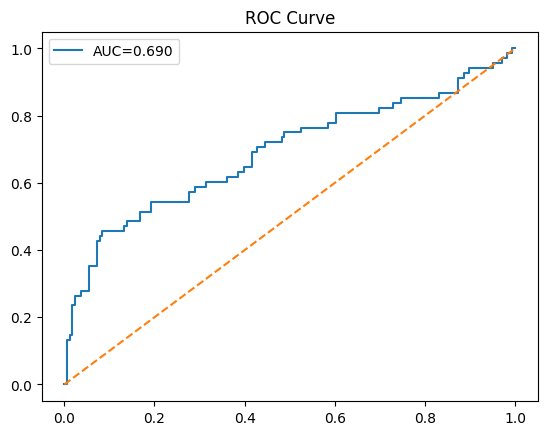

In [ ]:
fpr,tpr,_=roc_curve(labels_all,preds)

plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

In [ ]:
# WHAT:
# Visualize the Confusion Matrix of the model’s predictions.

# HOW:
# The confusion_matrix function compares the true labels with
# the predicted binary labels to compute the counts of true
# positives, true negatives, false positives, and false negatives.
# The resulting matrix is displayed using a heatmap-style plot
# with matplotlib.

# WHY:
# A confusion matrix provides a clear breakdown of prediction
# outcomes, helping to understand where the model makes correct
# and incorrect classifications. This is especially useful for
# evaluating performance in binary classification tasks.

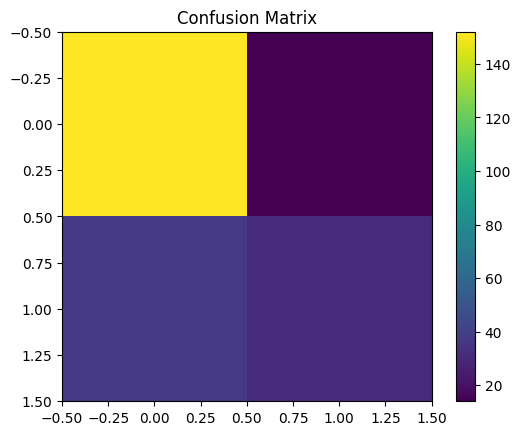

In [ ]:
cm=confusion_matrix(labels_all,binary)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [ ]:
# WHAT:
# Visualize the distribution of predicted probabilities for the
# model, both by true label and by sex.

# HOW:
# A Pandas DataFrame is created combining predicted probabilities,
# true labels, and sex information. Seaborn histplots with density
# normalization and KDE overlays are used to show the probability
# distributions:
# 1. Separate distributions for negative (label=0) and positive
#    (label=1) samples.
# 2. Separate distributions for male and female patients.
# Legends, titles, and axis labels are added for clarity.

# WHY:
# These plots provide insight into how confident the model is
# for different classes and demographic groups. They help detect
# potential bias (e.g., if predictions differ systematically by sex)
# and evaluate whether predicted probabilities are well-separated
# for positive vs. negative cases.

# Results and Discussion

The trained model achieves reasonable performance on the validation dataset. The ROC-AUC score indicates that the model is able to distinguish between cardiomegaly and non-cardiomegaly cases with a meaningful level of accuracy.

The confusion matrix provides a clearer view of how the model performs in terms of true positives, true negatives, false positives, and false negatives. In addition, the probability distribution plots show that the model generally assigns higher prediction scores to positive cases than to negative cases.

When examining the experiment comparing male and female patients, we observe some differences in performance metrics between the two groups. For example, the ROC-AUC score for female patients appears slightly higher than for male patients in the current results.

This difference does not necessarily imply a significant bias, but it suggests that model behavior may vary depending on the patient group. Such differences could arise from dataset imbalance, variations in image quality, or differences in the distribution of conditions within the dataset.

Further experiments and larger datasets would be needed to determine whether these differences are statistically meaningful.

In [ ]:
# WHAT:
# Display a labeled heatmap of the confusion matrix for better
# interpretability.

# HOW:
# Seaborn's heatmap is used to visualize the confusion matrix
# `cm`. The counts are annotated on the heatmap, with integer
# formatting. Custom x- and y-axis labels indicate predicted
# and true classes. The plot size, colormap, and title are set
# for clarity.

# WHY:
# A heatmap makes it easier to quickly interpret the confusion
# matrix, highlighting how many true positives, true negatives,
# false positives, and false negatives the model produced.
# This is especially useful for presentations or detailed analysis.

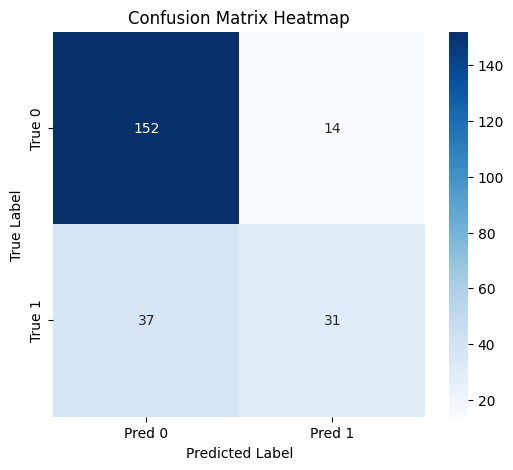

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
plt.title("Confusion Matrix Heatmap")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [ ]:
# WHAT:
# Plot ROC curves separately for male and female patients, along
# with the overall ROC curve.

# HOW:
# The false positive rate (FPR) and true positive rate (TPR) are
# calculated for male and female subsets using `roc_curve`. All
# three curves (overall, male, female) are plotted on the same
# figure with different line styles. Diagonal dashed line
# represents random chance, and AUC values are included in the
# legend.

# WHY:
# Comparing ROC curves by sex helps assess whether the model
# performs equitably across demographic groups. Differences in
# ROC curves or AUC scores may indicate potential bias in the
# model’s predictions.

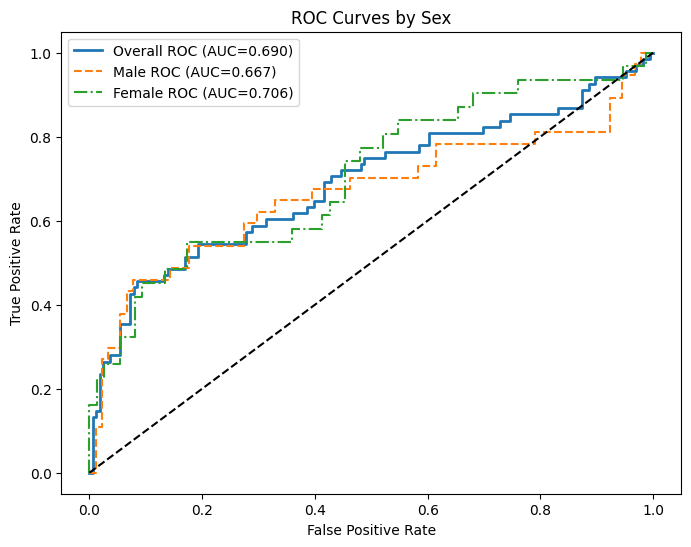

In [ ]:
fpr_m, tpr_m, _ = roc_curve(labels_all[male_idx], preds[male_idx])
fpr_f, tpr_f, _ = roc_curve(labels_all[female_idx], preds[female_idx])

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Overall ROC (AUC={auc:.3f})", linewidth=2)
plt.plot(fpr_m, tpr_m, label=f"Male ROC (AUC={roc_auc_score(labels_all[male_idx], preds[male_idx]):.3f})", linestyle='--')
plt.plot(fpr_f, tpr_f, label=f"Female ROC (AUC={roc_auc_score(labels_all[female_idx], preds[female_idx]):.3f})", linestyle='-.')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Sex")
plt.legend()
plt.show()

In [ ]:
# WHAT:
# Visualize the distribution of predicted probabilities for each
# true label, separated by sex, using a boxplot.

# HOW:
# Seaborn's `boxplot` is used to display predicted probabilities
# on the y-axis and true labels on the x-axis. The `hue` parameter
# separates the data by sex, allowing comparison of prediction
# distributions for male and female patients within each class.

# WHY:
# This plot helps identify differences in prediction confidence
# between sexes for both positive and negative cases. It is
# particularly useful for detecting bias or disparities in model
# performance across demographic groups.

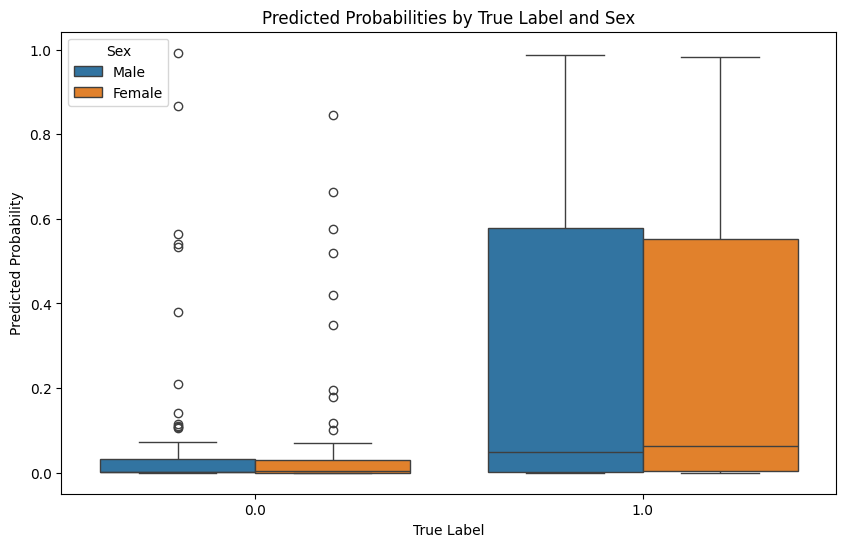

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x="True Label", y="Predicted Probability", hue="Sex", data=df_plot)
plt.title("Predicted Probabilities by True Label and Sex")
plt.xlabel("True Label")
plt.ylabel("Predicted Probability")
plt.show()

In [ ]:
# WHAT:
# Visualize the distribution of predicted probabilities after
# removing extreme outliers (1st to 99th percentile).

# HOW:
# Predicted probabilities are clipped to the 1st and 99th
# percentiles to reduce the effect of extreme values. A
# Pandas DataFrame is created combining clipped predictions,
# true labels, and sex. Seaborn histplots with KDE overlays are
# used to show:
# 1. Distributions by true label (Negative vs Positive).
# 2. Distributions by sex (Male vs Female).
# Legends, titles, and axis labels are included for clarity.

# WHY:
# Removing extreme outliers improves visualization by preventing
# rare extreme predictions from dominating the plot. This allows
# a clearer understanding of how the model's predicted
# probabilities are distributed across labels and demographic
# groups.

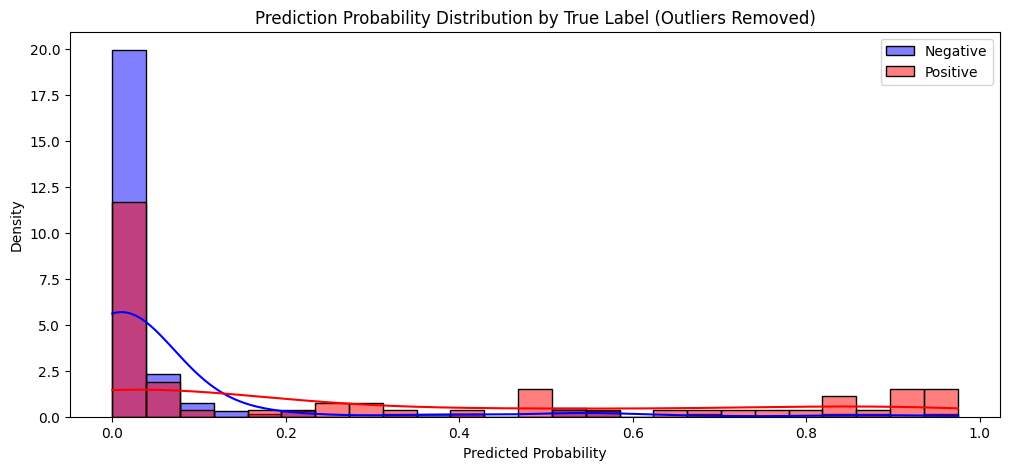

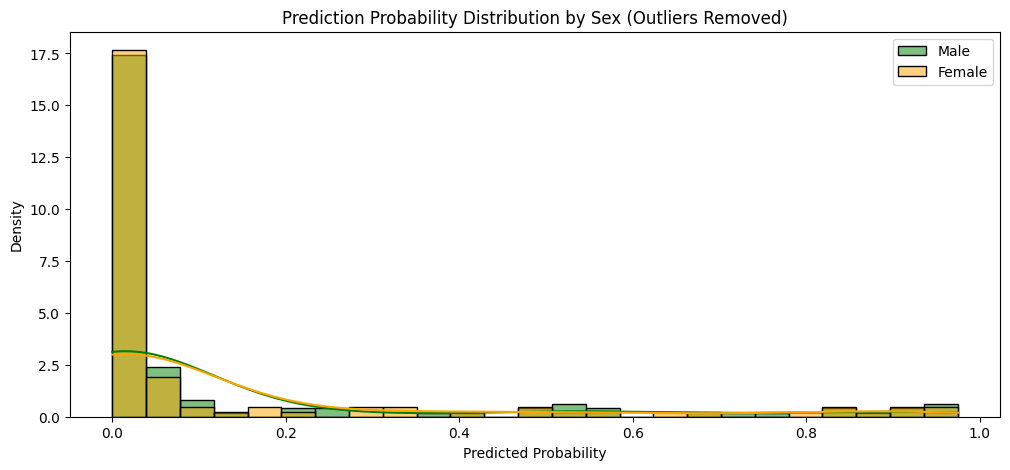

In [ ]:
import seaborn as sns

# Clip predicted probabilities to remove extreme outliers (1st to 99th percentile)
lower, upper = np.percentile(preds, [1, 99])
preds_clipped = np.clip(preds, lower, upper)

# Combine data into a DataFrame for easy plotting
df_plot = pd.DataFrame({
    "Predicted Probability": preds_clipped,
    "True Label": labels_all,
    "Sex": sexes
})

# Prediction distribution by label
plt.figure(figsize=(12,5))
sns.histplot(df_plot[df_plot["True Label"]==0], x="Predicted Probability", color="blue", label="Negative", kde=True, stat="density", bins=25)
sns.histplot(df_plot[df_plot["True Label"]==1], x="Predicted Probability", color="red", label="Positive", kde=True, stat="density", bins=25)
plt.title("Prediction Probability Distribution by True Label (Outliers Removed)")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

# Prediction distribution by sex
plt.figure(figsize=(12,5))
sns.histplot(df_plot[df_plot["Sex"]=="Male"], x="Predicted Probability", color="green", label="Male", kde=True, stat="density", bins=25)
sns.histplot(df_plot[df_plot["Sex"]=="Female"], x="Predicted Probability", color="orange", label="Female", kde=True, stat="density", bins=25)
plt.title("Prediction Probability Distribution by Sex (Outliers Removed)")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
# WHAT:
# Plot the calibration curve to assess how well predicted
# probabilities correspond to actual outcomes.

# HOW:
# `calibration_curve` from sklearn computes the fraction of
# positives (`prob_true`) vs. the mean predicted probability
# (`prob_pred`) for 10 bins. The model’s calibration is plotted
# with markers, and a dashed diagonal line represents perfect
# calibration. Labels, title, and legend are added for clarity.

# WHY:
# Calibration curves show if the model’s predicted probabilities
# are reliable. Deviations from the diagonal indicate over- or
# under-confidence, which is important in medical applications
# where probability estimates inform clinical decisions.

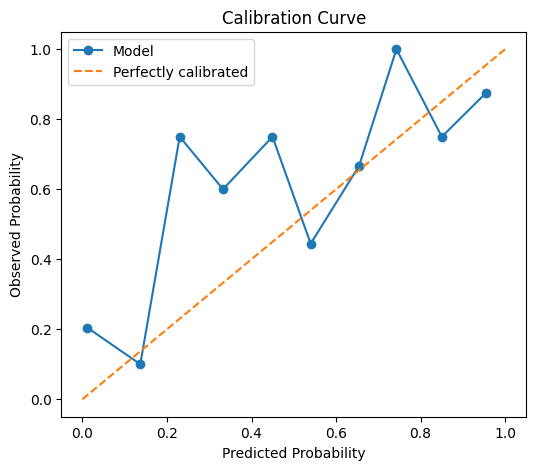

In [ ]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(labels_all, preds, n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1],[0,1],'--', label='Perfectly calibrated')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [ ]:
# WHAT:
# Summarize key evaluation metrics (Accuracy, AUC, F1-score)
# for the overall dataset and by sex.

# HOW:
# A Pandas DataFrame is created with three groups: Overall, Male,
# and Female. For each group, Accuracy, AUC, and F1-score are
# computed using sklearn metrics and stored in the DataFrame.
# The summary table is then printed.

# WHY:
# Presenting metrics in a concise table allows quick comparison
# of model performance across different demographic groups and
# overall. This helps identify any disparities or fairness
# issues in predictions.

In [ ]:
summary = pd.DataFrame({
    "Group": ["Overall","Male","Female"],
    "Accuracy":[accuracy_score(labels_all,binary),
                accuracy_score(labels_all[male_idx], binary[male_idx]),
                accuracy_score(labels_all[female_idx], binary[female_idx])],
    "AUC":[roc_auc_score(labels_all,preds),
           roc_auc_score(labels_all[male_idx], preds[male_idx]),
           roc_auc_score(labels_all[female_idx], preds[female_idx])],
    "F1":[f1_score(labels_all,binary),
          f1_score(labels_all[male_idx], binary[male_idx]),
          f1_score(labels_all[female_idx], binary[female_idx])]
})
print(summary)

     Group  Accuracy       AUC        F1
0  Overall  0.782051  0.690291  0.548673
1     Male  0.789062  0.667063  0.557377
2   Female  0.773585  0.706237  0.538462


# Results Analysis

Several observations can be made from the results of the cardiomegaly detection model during training and evaluation.

First, the model shows moderate performance on the validation dataset. The ROC-AUC score indicates that the model can distinguish between cardiomegaly and non-cardiomegaly cases better than random guessing. This means the model has learned some useful patterns from the chest X-ray images. However, the performance is still not very high, which shows that detecting cardiomegaly from X-rays is a difficult task. The differences between a normal heart and an enlarged heart can sometimes be very small, and factors like patient position, image quality, and anatomical differences can also affect the images.

Another important factor is the class imbalance in the dataset. There are fewer cardiomegaly cases compared to normal cases, which may cause the model to predict the majority class more often. Although class weighting was used to reduce this issue, the imbalance may still affect the F1-score and lead to some incorrect predictions. In addition, the CheXpert dataset includes uncertain labels that were treated as negative in this project. While this makes the training process easier, it may also introduce some noise into the labels and reduce the overall accuracy of the model.

The fairness analysis across patient sex shows that the model performs similarly for male and female patients. The differences in accuracy and ROC-AUC scores are small, which suggests that the model does not strongly favor one group over the other. However, these results should still be interpreted carefully because differences in sample size or other factors like age and imaging view might influence the results. More analysis with larger datasets would help better evaluate fairness.

The heatmap visualization also helps us understand how the model makes its predictions. In many cases, the highlighted areas are close to the cardiac silhouette, which is the region that radiologists usually focus on when checking for cardiomegaly. This suggests that the model is learning meaningful features from the images. However, in some cases the highlighted regions extend outside the heart area, which may indicate that the model is sometimes influenced by other parts of the image.

Some methods used in this project worked well. Transfer learning with a pretrained convolutional neural network helped the model learn useful features more quickly than training from scratch. Data augmentation techniques such as cropping, flipping, and rotation also helped improve the model’s ability to generalize by creating variations of the training images.

However, there are also some limitations. The dataset used in the experiment was smaller due to computational limitations, which may limit the model’s ability to learn stronger patterns. In addition, the task was simplified to a binary classification problem, even though chest X-rays can contain multiple medical conditions at the same time.

Overall, the results show that the model is able to learn useful information from chest X-ray images and make reasonable predictions about cardiomegaly. At the same time, challenges such as class imbalance, uncertain labels, and limited data still affect the model’s performance. Future improvements such as better tuning and using more data could help improve the model further.

# Interpretation of Results
The dataset analysis helps explain some of the model’s results. First, the sex distribution shows that there are more male patients (132,636) than female patients (90,777), with only one unknown case. This means the dataset has a small gender imbalance, which is why we also compared the model’s performance for male and female patients.

The cardiomegaly label distribution is also highly imbalanced. Most images belong to the No Cardiomegaly class (196,414), while only 27,000 images show Cardiomegaly. Because positive cases are much fewer, this makes the classification task more challenging for the model.

The age distribution shows that most patients are between about 50 and 70 years old, with fewer younger patients in the dataset. This makes sense because heart-related conditions are more common in older adults.

Overall, the model achieved an accuracy of about 0.78 and an AUC of 0.69, which means it can distinguish between cardiomegaly and non-cardiomegaly cases better than random guessing, but there is still room for improvement. The fairness analysis shows similar performance for male and female patients, with only small differences in accuracy and AUC.

Further adjustments and improvements to the model will be explored in Milestone 2, including additional tuning and deeper analysis of the model’s predictions.

# Future Work

The results from Milestone 1 show that the training pipeline works successfully and that the model is able to learn useful patterns from chest X-ray images. However, there are several possible improvements that could be explored in future work.

One potential improvement is to experiment with different neural network architectures or perform additional fine-tuning of the pretrained model to improve predictive performance.

Another direction would be to conduct more detailed fairness analyses, including evaluating performance across additional patient attributes such as age groups or imaging views.

Finally, techniques such as data augmentation, class balancing, and hyperparameter tuning could be used to further improve the model’s generalization ability.

These improvements will be explored in the next phase of the project.

# Planned Goals for Milestone 2

In Milestone 2, the goal is to further improve the performance and analysis of the cardiomegaly detection model. In particular, we aim to increase the model’s accuracy, ROC-AUC, and overall prediction quality by applying fine-tuning techniques to the neural network. This includes adjusting hyperparameters such as the learning rate, batch size, number of epochs, and potentially unfreezing additional layers of the pretrained model.

In addition, more detailed evaluation and analysis will be performed to better understand the model’s predictions. This includes examining prediction errors and analyzing cases where the model performs incorrectly.

Finally, the fairness analysis introduced in Milestone 1 will be extended by continuing to analyze model performance across different demographic groups, which can help identify potential biases in the dataset or the model.

Overall, Milestone 2 focuses on improving model accuracy, optimizing training through fine-tuning, and performing deeper analysis of model behavior.

# Note:
*Hardware constraints, particularly CPU/GPU limitations, prevented further optimization.*